
#  Inventory Forecasting - Model Training
 
 # Objectives
 1. Train multiple ML models for demand forecasting
 2. Evaluate model performance
 3. Select the best performing model
 4. Analyze feature importance

In [6]:
!pip install xgboost

   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.5/72.0 MB 1.3 MB/s eta 0:00:55
   ---------------------------------------- 0.5/72.0 MB 1.3 MB/s eta 0:00:55
   ---------------------------------------- 0.8/72.0 MB 1.1 MB/s eta 0:01:03
    --------------------------------------- 1.0/72.0 MB 1.0 MB/s eta 0:01:10
    --------------------------------------- 1.3/72.0 MB 1.0 MB/s eta 0:01:10
    --------------------------------------- 1.3/72.0 MB 1.0 MB/s eta 0:01:10
    --------------------------------------- 1.6/72.0 MB 995.8 kB/s eta 0:01:11
   - -------------------------------------- 1.8/72.0 MB 955.3 kB/s eta 0:01:14
   - -------------------------------------- 1.8/72.0 MB 955.3 kB/s eta 0:01:14
   - -------------------------------------- 2.1/72.0 MB 909.9 kB/s eta 0:01:17
   - -------------------------------------- 2.1/72.0 MB 909.9 kB/s eta 0:01:17
   


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, TimeSeriesSplit
import xgboost as xgb
import joblib
import warnings
warnings.filterwarnings('ignore')

In [7]:
# Load engineered features
df = pd.read_csv('C:/Users/dubey/Desktop/inventory forecasting project/data/engineered_features.csv')
print(f"Dataset loaded: {df.shape}")


Dataset loaded: (6479, 52)


In [8]:
# Prepare features and target
feature_columns = [col for col in df.columns if col not in [
    'Date', 'Bar Name', 'Alcohol Type', 'Brand Name', 
    'Next_Day_Consumption', 'Consumed (ml)', 'Purchase (ml)',
    'Opening Balance (ml)', 'Closing Balance (ml)'
]]

X = df[feature_columns]
y = df['Next_Day_Consumption']

print(f"Features: {X.shape}")
print(f"Target: {y.shape}")

Features: (6479, 43)
Target: (6479,)


In [9]:
# Time-based train-test split
df['Date'] = pd.to_datetime(df['Date'])
split_date = df['Date'].quantile(0.8)  # 80% for training, 20% for testing

train_mask = df['Date'] <= split_date
test_mask = df['Date'] > split_date

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")
print(f"Split date: {split_date.date()}")

Training set: 5194 samples
Testing set: 1285 samples
Split date: 2023-10-15


In [10]:
# Initialize models
models = {
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': xgb.XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'LinearRegression': LinearRegression()
}


In [11]:
# Train and evaluate models
results = {}
feature_importances = {}

for name, model in models.items():
    print(f"Training {name}...")
    
    # Train model
    model.fit(X_train, y_train)
    
    # Predictions
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    # Calculate metrics
    train_mae = mean_absolute_error(y_train, y_pred_train)
    test_mae = mean_absolute_error(y_test, y_pred_test)
    
    train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    
    train_r2 = r2_score(y_train, y_pred_train)
    test_r2 = r2_score(y_test, y_pred_test)
    
    # Mean Absolute Percentage Error (MAPE)
    train_mape = np.mean(np.abs((y_train - y_pred_train) / (y_train + 1))) * 100
    test_mape = np.mean(np.abs((y_test - y_pred_test) / (y_test + 1))) * 100
    
    results[name] = {
        'Train_MAE': train_mae,
        'Test_MAE': test_mae,
        'Train_RMSE': train_rmse,
        'Test_RMSE': test_rmse,
        'Train_R2': train_r2,
        'Test_R2': test_r2,
        'Train_MAPE': train_mape,
        'Test_MAPE': test_mape
    }

Training RandomForest...
Training XGBoost...
Training GradientBoosting...
Training LinearRegression...


In [12]:
    # Feature importance
    if hasattr(model, 'feature_importances_'):
        feature_importances[name] = pd.DataFrame({
            'feature': X.columns,
            'importance': model.feature_importances_
        }).sort_values('importance', ascending=False)
    
    print(f"  {name} - Test MAPE: {test_mape:.2f}%")

  LinearRegression - Test MAPE: 2859.40%


In [13]:
# Results comparison
results_df = pd.DataFrame(results).T
print("\n=== MODEL PERFORMANCE COMPARISON ===")
print(results_df.round(3))


=== MODEL PERFORMANCE COMPARISON ===
                  Train_MAE  Test_MAE  Train_RMSE  Test_RMSE  Train_R2  \
RandomForest         49.973   144.688      63.318    177.431     0.890   
XGBoost              39.441   149.697      52.889    188.098     0.923   
GradientBoosting    123.237   140.321     152.177    173.475     0.366   
LinearRegression    145.514   150.616     175.897    182.890     0.152   

                  Test_R2  Train_MAPE  Test_MAPE  
RandomForest        0.175     687.286   2633.581  
XGBoost             0.073     542.024   2595.930  
GradientBoosting    0.212    1718.293   2136.697  
LinearRegression    0.124    2841.151   2859.400  


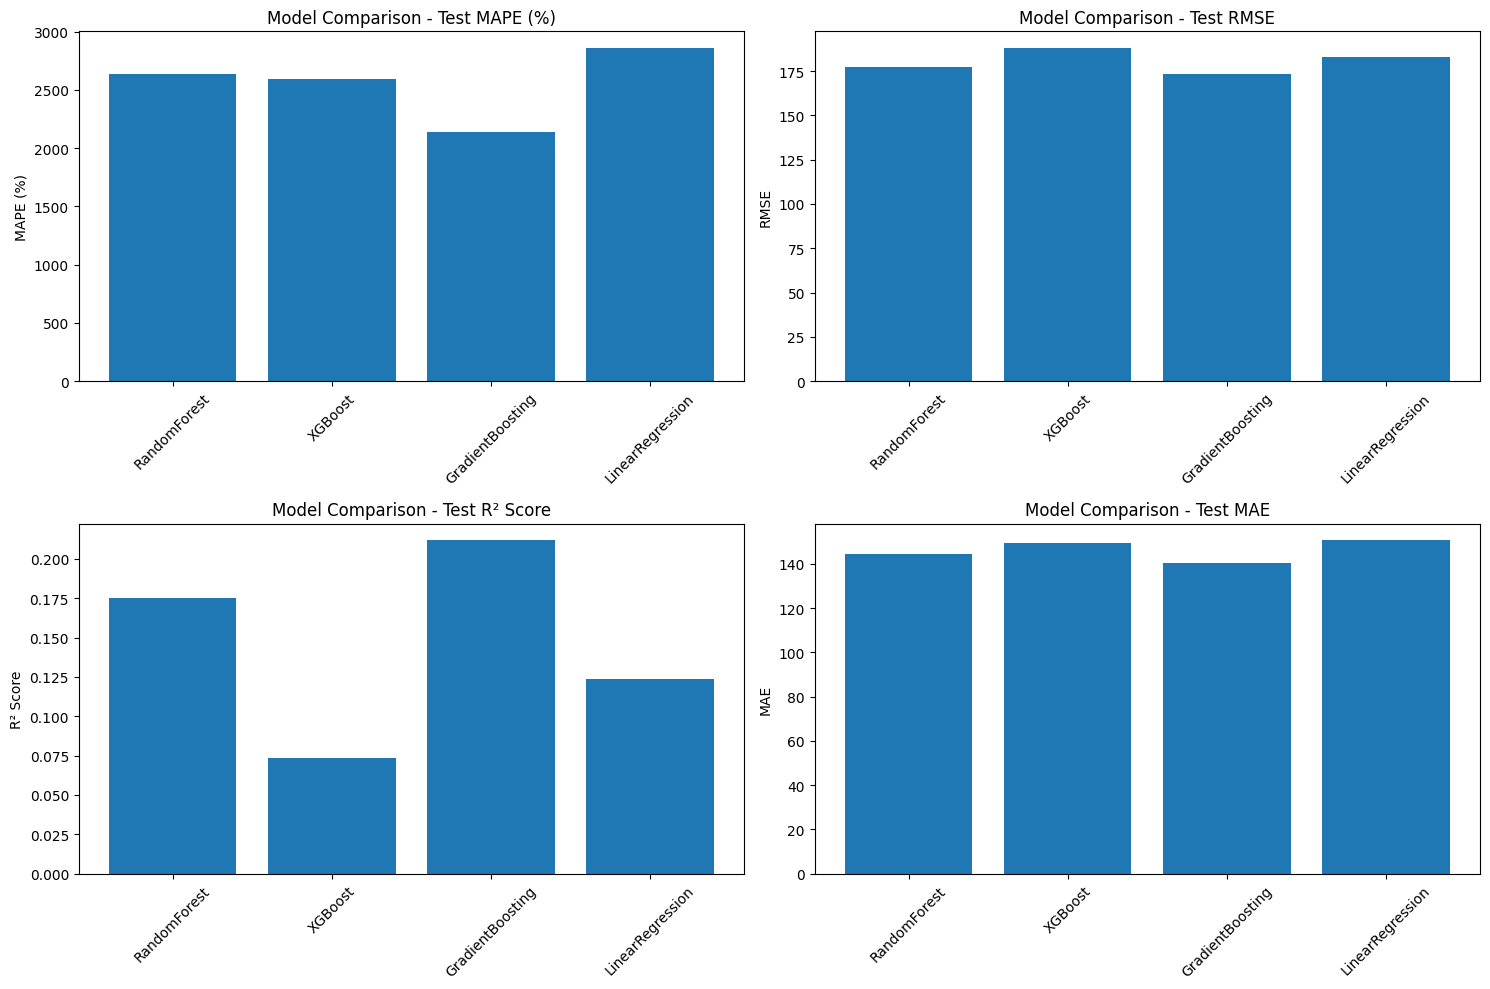

In [16]:
# Visualize model performance
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# MAPE comparison
axes[0, 0].bar(results_df.index, results_df['Test_MAPE'])
axes[0, 0].set_title('Model Comparison - Test MAPE (%)')
axes[0, 0].set_ylabel('MAPE (%)')
axes[0, 0].tick_params(axis='x', rotation=45)

# RMSE comparison
axes[0, 1].bar(results_df.index, results_df['Test_RMSE'])
axes[0, 1].set_title('Model Comparison - Test RMSE')
axes[0, 1].set_ylabel('RMSE')
axes[0, 1].tick_params(axis='x', rotation=45)

# R² comparison
axes[1, 0].bar(results_df.index, results_df['Test_R2'])
axes[1, 0].set_title('Model Comparison - Test R² Score')
axes[1, 0].set_ylabel('R² Score')
axes[1, 0].tick_params(axis='x', rotation=45)

# MAE comparison
axes[1, 1].bar(results_df.index, results_df['Test_MAE'])
axes[1, 1].set_title('Model Comparison - Test MAE')
axes[1, 1].set_ylabel('MAE')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [17]:
# Select best model based on MAPE
best_model_name = results_df['Test_MAPE'].idxmin()
best_model = models[best_model_name]
best_performance = results_df.loc[best_model_name]

print(f"\n=== BEST MODEL: {best_model_name} ===")
print(f"Test MAPE: {best_performance['Test_MAPE']:.2f}%")
print(f"Test RMSE: {best_performance['Test_RMSE']:.2f}")
print(f"Test R²: {best_performance['Test_R2']:.3f}")



=== BEST MODEL: GradientBoosting ===
Test MAPE: 2136.70%
Test RMSE: 173.47
Test R²: 0.212


In [18]:
# Feature importance analysis for the best model
if best_model_name in feature_importances:
    top_features = feature_importances[best_model_name].head(15)
    
    plt.figure(figsize=(12, 8))
    plt.barh(top_features['feature'], top_features['importance'])
    plt.title(f'Top 15 Feature Importance - {best_model_name}')
    plt.xlabel('Importance')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    print("\nTop 10 Most Important Features:")
    for idx, row in top_features.head(10).iterrows():
        print(f"  {row['feature']}: {row['importance']:.4f}")

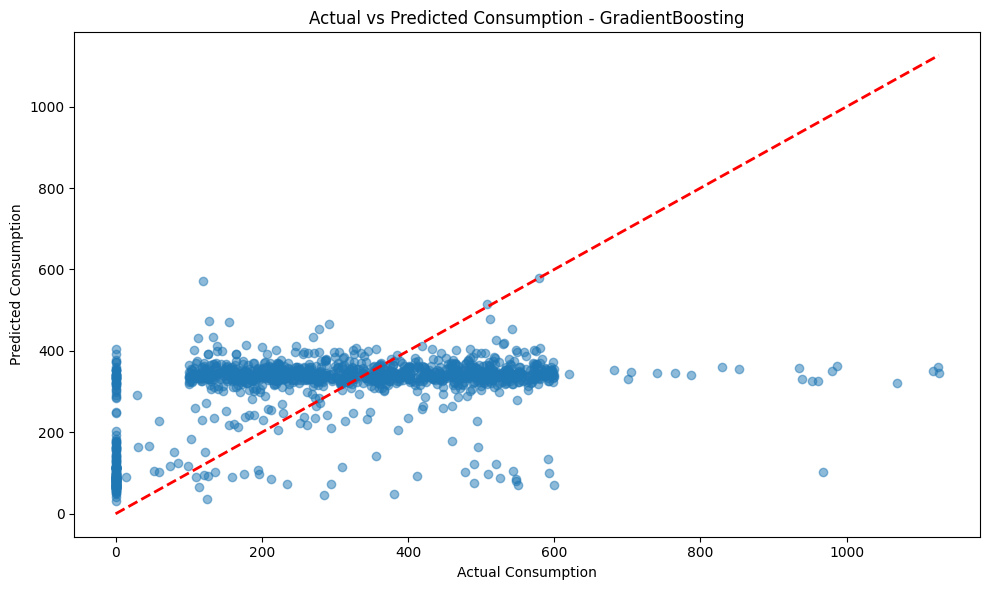

In [19]:
# Actual vs Predicted for best model
y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_best, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Consumption')
plt.ylabel('Predicted Consumption')
plt.title(f'Actual vs Predicted Consumption - {best_model_name}')
plt.tight_layout()
plt.show()

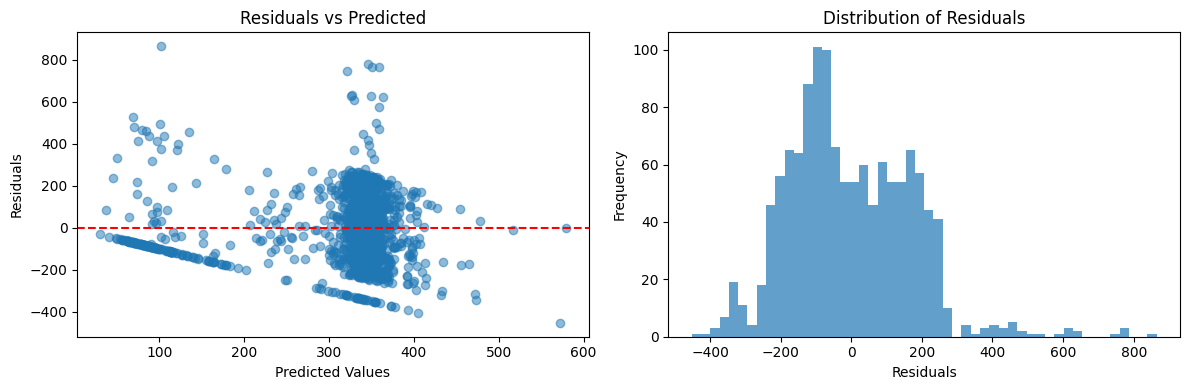

In [20]:
# Residual analysis
residuals = y_test - y_pred_best

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.scatter(y_pred_best, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted')

plt.subplot(1, 2, 2)
plt.hist(residuals, bins=50, alpha=0.7)
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Distribution of Residuals')

plt.tight_layout()
plt.show()

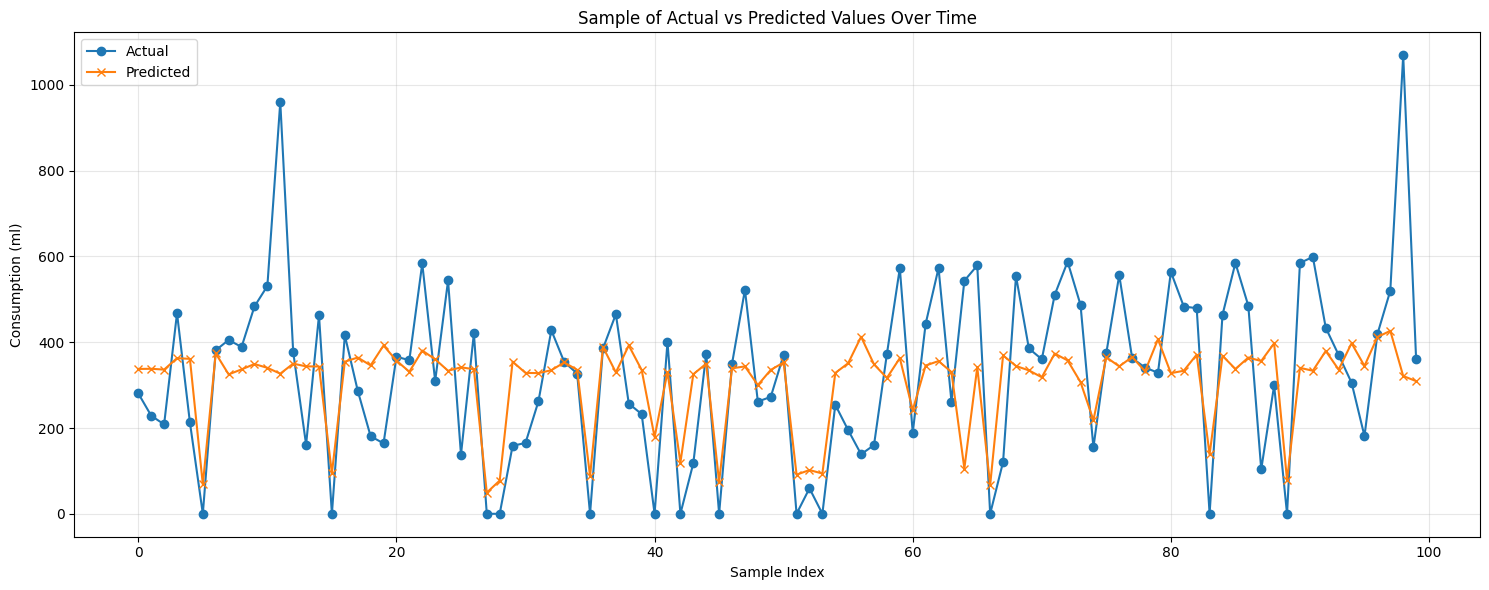

In [21]:
# Time series of predictions vs actuals (sample of data)
sample_size = min(100, len(y_test))
sample_indices = np.random.choice(len(y_test), sample_size, replace=False)

plt.figure(figsize=(15, 6))
plt.plot(range(sample_size), y_test.iloc[sample_indices].values, label='Actual', marker='o')
plt.plot(range(sample_size), y_pred_best[sample_indices], label='Predicted', marker='x')
plt.xlabel('Sample Index')
plt.ylabel('Consumption (ml)')
plt.title('Sample of Actual vs Predicted Values Over Time')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [22]:
# Save the best model
model_filename = f'../models/best_model_{best_model_name}.pkl'
joblib.dump(best_model, model_filename)
print(f"Best model saved as: {model_filename}")



Best model saved as: ../models/best_model_GradientBoosting.pkl


In [23]:
# Save predictions for inventory optimization
predictions_df = df[test_mask].copy()
predictions_df['Predicted_Consumption'] = y_pred_best
predictions_df['Actual_Consumption'] = y_test.values
predictions_df['Residual'] = residuals.values

predictions_df[['Date', 'Bar Name', 'Alcohol Type', 'Brand Name', 
                'Actual_Consumption', 'Predicted_Consumption', 'Residual']].to_csv(
    '../results/model_predictions.csv', index=False)

print("Predictions saved to '../results/model_predictions.csv'")

Predictions saved to '../results/model_predictions.csv'


In [24]:
# Performance by product category
performance_by_alcohol = predictions_df.groupby('Alcohol Type').apply(
    lambda x: pd.Series({
        'MAE': mean_absolute_error(x['Actual_Consumption'], x['Predicted_Consumption']),
        'MAPE': np.mean(np.abs((x['Actual_Consumption'] - x['Predicted_Consumption']) / 
                              (x['Actual_Consumption'] + 1))) * 100,
        'Samples': len(x)
    })
).round(3)

print("\n=== PERFORMANCE BY ALCOHOL TYPE ===")
print(performance_by_alcohol)


=== PERFORMANCE BY ALCOHOL TYPE ===
                  MAE      MAPE  Samples
Alcohol Type                            
Beer          142.130  2562.854    234.0
Rum           131.990  1957.587    269.0
Vodka         143.461  1251.086    264.0
Whiskey       148.730  3040.526    264.0
Wine          135.476  1914.845    254.0


In [25]:
# Performance by bar
performance_by_bar = predictions_df.groupby('Bar Name').apply(
    lambda x: pd.Series({
        'MAE': mean_absolute_error(x['Actual_Consumption'], x['Predicted_Consumption']),
        'MAPE': np.mean(np.abs((x['Actual_Consumption'] - x['Predicted_Consumption']) / 
                              (x['Actual_Consumption'] + 1))) * 100,
        'Samples': len(x)
    })
).round(3)

print("\n=== PERFORMANCE BY BAR ===")
print(performance_by_bar)


=== PERFORMANCE BY BAR ===
                    MAE      MAPE  Samples
Bar Name                                  
Anderson's Bar  137.401  2310.058    216.0
Brown's Bar     145.164  2443.834    220.0
Johnson's Bar   131.211  1298.472    211.0
Smith's Bar     140.104  1451.166    215.0
Taylor's Bar    149.710  2674.826    212.0
Thomas's Bar    138.160  2635.060    211.0


In [26]:
print("\n=== MODEL TRAINING COMPLETED ===")
print(f"Best Model: {best_model_name}")
print(f"Test MAPE: {best_performance['Test_MAPE']:.2f}%")
print(f"Test R²: {best_performance['Test_R2']:.3f}")
print(f"Model saved and ready for inventory optimization!")



=== MODEL TRAINING COMPLETED ===
Best Model: GradientBoosting
Test MAPE: 2136.70%
Test R²: 0.212
Model saved and ready for inventory optimization!
